# Time Series Activity Forecasting Process

This notebook outlines a detailed process for forecasting activity (e.g., "seen" events) for various indicators over time using a combination of feature engineering, statistical models, machine learning, and ensemble methods. Below is a step-by-step description of the workflow:

---

## 1. Data Loading and Preparation

- **Data Source:** The data is loaded from a CSV file containing time series records for multiple indicators.
- **Preprocessing:**
    - The `date` column is parsed as a datetime object.
    - Data is sorted by `indicator` and `date`.
    - Only the most recent `n_days` (e.g., 100) are retained for analysis.
    - The resulting DataFrame (`df`) contains columns such as `API_UserName`, `date`, `indicator`, `observations`, `dayofweek`, `is_weekend`, `day`, `month`, and `seen`.

---

## 2. Feature Engineering

- **Time Series Features:** For each indicator, the following features are extracted:
    - `last_seen`: Days since the indicator was last seen.
    - `freq_7`, `freq_30`: Number of times seen in the last 7 and 30 days.
    - `avg_gap`: Average gap between seen events.
    - `burstiness`: Variability in the gaps between events.
    - `label_7`, `label_14`, `label_30`: Binary labels indicating if the indicator was seen in the last 7, 14, or 30 days.
- **Output:** A features DataFrame (`features_df`) indexed by indicator.

---

## 3. Model Training and Prediction

- **Models Used:**
    - **Logistic Regression:** Predicts the probability of being seen in the next 7, 14, or 30 days.
    - **Gradient Boosted Trees (GBT):** Another probabilistic classifier for the same task.
    - **Exponential Model:** Uses recent frequency to estimate the probability of being seen.
    - **Weibull AFT Model:** Survival analysis model to estimate the probability of future events.
- **Predictions:** For each indicator, probabilities are computed for being seen today, in 7, 14, and 30 days.

---

## 4. Rule-Based and Ensemble Methods

- **Rule-Based Labels:** Simple heuristics based on `last_seen` (e.g., if last seen within 7 days, label as active).
- **Logistic Model on Rules:** Trains a logistic regression model using the rule-based labels.
- **Ensemble:** Combines probabilities from the logistic model, GBT, Weibull, and exponential models using weighted averages to improve robustness.

---

## 5. Confidence Assessment and Formatting

- **Confidence Labels:** For each forecast window (today, 7d, 14d, 30d), assigns a qualitative confidence label (e.g., "Highly likely", "Possibly active", "Low confidence") based on probability thresholds and recent frequency.
- **Formatting:** Probabilities are formatted as percentages for presentation.

---

## Summary

This process enables robust, interpretable, and actionable forecasting of indicator activity using a blend of statistical and machine learning techniques, with clear outputs for operational use.

In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
import warnings

def load_data(filepath, n_days=100):
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values(by=['indicator', 'date'], inplace=True)
    latest_dates = df['date'].drop_duplicates().sort_values().tail(n_days)
    return df[df['date'].isin(latest_dates)].copy()

def extract_time_series_features(group):
    series = group['seen'].values
    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })
    last_seen = len(series) - 1 - indices[-1]
    freq_7 = np.sum(series[-7:])
    freq_30 = np.sum(series[-30:])
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series)
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0
    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

def build_features(df):
    features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()
    return features_df

def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def fit_weibull_aft(X, avg_gap, event):
    aft_df = X.copy()
    aft_df['duration'] = avg_gap
    aft_df['event'] = event
    aft = WeibullAFTFitter()
    aft.fit(aft_df, duration_col='duration', event_col='event')
    return aft

def get_model_outputs(features_df, df):
    df_pred = features_df.copy()
    X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
    y_7 = df_pred['label_7']
    y_14 = df_pred['label_14']
    y_30 = df_pred['label_30']

    # Logistic Regression
    df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
    df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
    df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

    # Gradient Boosted Trees
    df_pred['gbt_7'] = train_gbt(X, y_7)
    df_pred['gbt_14'] = train_gbt(X, y_14)
    df_pred['gbt_30'] = train_gbt(X, y_30)

    # Exponential Model
    rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
    df_pred['exp_7'] = 1 - np.exp(-rate * 7)
    df_pred['exp_14'] = 1 - np.exp(-rate * 14)
    df_pred['exp_30'] = 1 - np.exp(-rate * 30)
    df_pred['exp_today'] = 1 - np.exp(-rate * 1)

    # Weibull AFT Model
    aft = fit_weibull_aft(X, df_pred['avg_gap'], y_7)
    surv_func = aft.predict_survival_function(X.assign(duration=df_pred['avg_gap'], event=y_7), times=[1, 7, 14, 30])
    df_pred['weibull_today'] = 1 - surv_func.loc[1].values
    df_pred['weibull_7'] = 1 - surv_func.loc[7].values
    df_pred['weibull_14'] = 1 - surv_func.loc[14].values
    df_pred['weibull_30'] = 1 - surv_func.loc[30].values

    # Today's forecast
    df_pred['logistic_today'] = train_predict(LogisticRegression, X, y_7)
    df_pred['gbt_today'] = train_gbt(X, y_7)

    # Merge in actual "seen" value for today's date
    latest_date = df['date'].max()
    today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
    df_pred = df_pred.merge(today_seen, on='indicator', how='left')

    return df_pred

def add_rule_and_ensemble(output):
    features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
    X = output[features]

    # Rule-based labels
    output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
    output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
    output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
    output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

    y_today = output['rule_today']
    y_7 = output['rule_7d']
    y_14 = output['rule_14d']
    y_30 = output['rule_30d']

    def train_logistic_model(X, y):
        if len(np.unique(y)) < 2:
            return np.full(len(y), np.nan)
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression())
        ])
        model.fit(X, y)
        return model.predict_proba(X)[:, 1]

    output['prob_today'] = train_logistic_model(X, y_today)
    output['prob_7d'] = train_logistic_model(X, y_7)
    output['prob_14d'] = train_logistic_model(X, y_14)
    output['prob_30d'] = train_logistic_model(X, y_30)

    # Ensemble
    output['ensemble_7d'] = (
        0.3 * output['prob_7d'].astype(float) +
        0.25 * output['gbt_7'] +
        0.25 * output['weibull_7'] +
        0.3 * output['exp_7']
    )
    output['ensemble_14d'] = (
        0.3 * output['prob_14d'].astype(float) +
        0.25 * output['gbt_14'] +
        0.25 * output['weibull_14'] +
        0.3 * output['exp_14']
    )
    output['ensemble_30d'] = (
        0.3 * output['prob_30d'].astype(float) +
        0.25 * output['gbt_30'] +
        0.25 * output['weibull_30'] +
        0.3 * output['exp_30']
    )
    return output

def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

def add_confidence_and_format(output):
    output['confidence_today'] = output.apply(
        lambda row: classify_window(row['prob_today'], row['freq_7'], 0.6, 'Today'), axis=1
    )
    output['confidence_7d'] = output.apply(
        lambda row: classify_window(row['ensemble_7d'], row['freq_7'], 0.6, '7-Day'), axis=1
    )
    output['confidence_14d'] = output.apply(
        lambda row: classify_window(row['ensemble_14d'], row['freq_7'], 0.6, '14-Day'), axis=1
    )
    output['confidence_30d'] = output.apply(
        lambda row: classify_window(row['ensemble_30d'], row['freq_7'], 0.6, '30-Day'), axis=1
    )

    # Format percentages
    for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
        output[col] = np.clip(output[col].astype(float) * 100, 0, 100).round(2).astype(str) + '%'
    output['prob_today'] = np.clip(output['prob_today'].astype(float) * 100, 0, 100).round(2).astype(str) + '%'
    return output

def build_production_output(output):
    warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
    production_output = output[[
        'indicator', 'seen_today', 'freq_7', 'freq_30',
        'prob_today', 'confidence_today',
        'ensemble_7d', 'confidence_7d',
        'ensemble_14d', 'confidence_14d',
        'ensemble_30d', 'confidence_30d'
    ]].copy()
    production_output.rename(columns={
        'indicator': 'Indicator',
        'seen_today': 'Observed Today',
        'freq_7': 'Frequency (7d)',
        'freq_30': 'Frequency (30d)',
        'prob_today': 'Probability: Today',
        'confidence_today': 'Confidence: Today',
        'ensemble_7d': 'Probability: 7-Day',
        'confidence_7d': 'Confidence: 7-Day',
        'ensemble_14d': 'Probability: 14-Day',
        'confidence_14d': 'Confidence: 14-Day',
        'ensemble_30d': 'Probability: 30-Day',
        'confidence_30d': 'Confidence: 30-Day'
    }, inplace=True)
    return production_output

def main():
    # Filepath to your data
    data_path = r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv'
    df = load_data(data_path)
    features_df = build_features(df)
    output = get_model_outputs(features_df, df)
    output = add_rule_and_ensemble(output)
    output = add_confidence_and_format(output)
    production_output = build_production_output(output)
    # Save or display
    #production_output.to_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\production_output.csv', index=False)
    display(production_output)

if __name__ == "__main__":
    main()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_17628\1691570961.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,1-you.njalla.no,0,1.0,1.0,12.93%,Today: Possibly active,58.99%,7-Day: Possibly active,65.97%,14-Day: Possibly active,75.06%,30-Day: Possibly active
1,102.90.61.13,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
2,102.91.94.193,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
3,103.108.231.67,0,0.0,1.0,0.04%,Today: Low confidence,6.4%,7-Day: Low confidence,11.6%,14-Day: Low confidence,63.06%,30-Day: Low confidence
4,103.133.107.28,0,4.0,14.0,44.41%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
...,...,...,...,...,...,...,...,...,...,...,...,...
576,www.3u.com,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.29%,30-Day: Low confidence
577,www.deepseek.com,1,7.0,25.0,86.25%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
578,www.deepseek.com.cdn.cloudflare.net,0,5.0,23.0,45.97%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
579,www.filemail.com,0,0.0,2.0,0.79%,Today: Low confidence,24.17%,7-Day: Low confidence,87.52%,14-Day: Low confidence,100.0%,30-Day: Low confidence


In [ ]:
#production_output.to_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\production_output.csv', index=False)

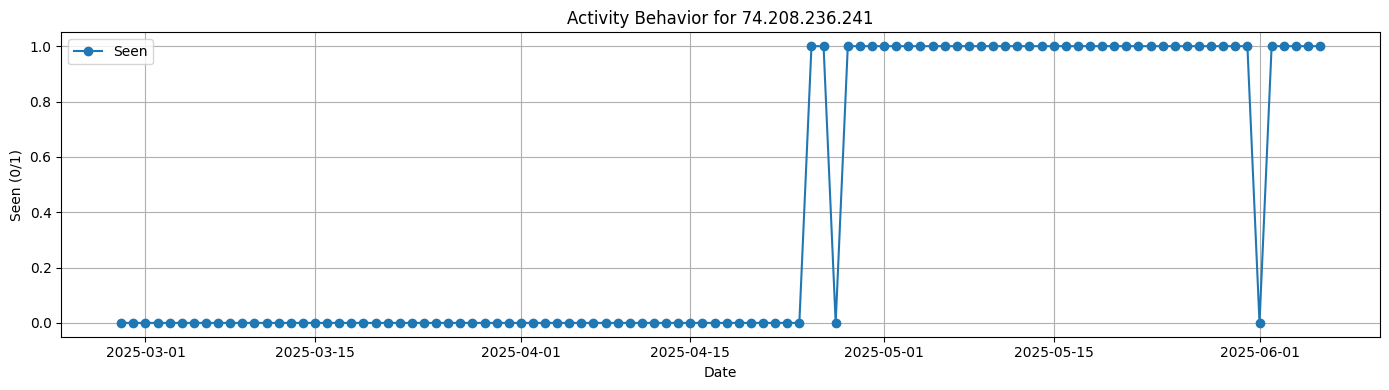

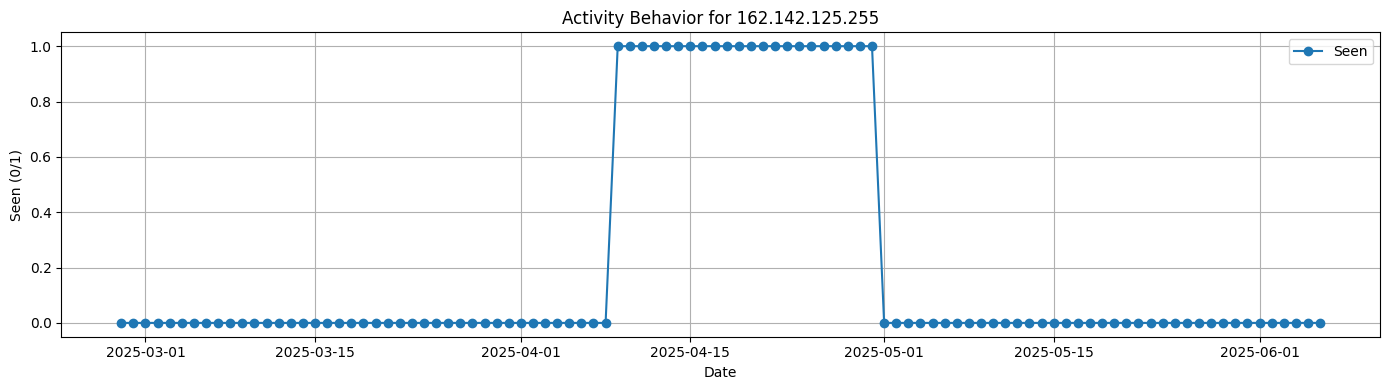

In [4]:
import matplotlib.pyplot as plt

# List of indicator IDs to plot
indicator_ids = ['74.208.236.241', '162.142.125.255']  # Add more as needed

for indicator_id in indicator_ids:
    df_plot = df[df['indicator'] == indicator_id].sort_values('date')

    plt.figure(figsize=(14, 4))
    plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
    plt.title(f'Activity Behavior for {indicator_id}')
    plt.xlabel('Date')
    plt.ylabel('Seen (0/1)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()